# 03 Spatial Architecture: Promoter Constraint with Upstream Redistribution

In [89]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

def _resolve_project_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'config.py').exists():
            return candidate
    raise FileNotFoundError('config.py not found in cwd or parents')

PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/markus/in-silico-vg-analysis


In [90]:
from config import (
    GENE_PATHS,
    VARIANT_PATHS,
    SOURCE_PALETTE,
    DISPLAY_NAMES,
    DISPLAY_NAMES_SHORT,
)
from utils.plot_utils import save_plot, autosave

NOTEBOOK_NAME = 'final_figure'

print('\nDatasets:')
for name in ['clingen', 'clingen_null', 'background', 'background_null']:
    print(f'  {name}: {GENE_PATHS[name].name}')


Datasets:
  clingen: ClinGen_HI_Gnomad_genes_21022026.parquet
  clingen_null: ClinGen_HI_Synth_genes_21022026.parquet
  background: Background_Gnomad_genes_21022026.parquet
  background_null: Background_Synth_genes_21022026.parquet


In [91]:
real_gene_dfs = []
synth_gene_dfs = []

for key, path in GENE_PATHS.items():
    lf = pl.scan_parquet(path).with_columns(pl.lit(key).alias('source'))
    if 'null' in key:
        synth_gene_dfs.append(lf)
    else:
        real_gene_dfs.append(lf)

df_real = pl.concat(real_gene_dfs).collect()
df_synth = pl.concat(synth_gene_dfs).collect()

df_hi = df_real.filter(pl.col('source') == 'clingen')
df_bg = df_real.filter(pl.col('source') == 'background')
df_hi_synth = df_synth.filter(pl.col('source') == 'clingen_null')
df_bg_synth = df_synth.filter(pl.col('source') == 'background_null')

print(f'ClinGen HI: {df_hi.height} genes')
print(f'Background: {df_bg.height} genes')
print(f'ClinGen HI (Synth): {df_hi_synth.height} genes')
print(f'Background (Synth): {df_bg_synth.height} genes')

ClinGen HI: 316 genes
Background: 349 genes
ClinGen HI (Synth): 316 genes
Background (Synth): 349 genes


In [92]:
real_variant_dfs = []
synth_variant_dfs = []

for key, path in VARIANT_PATHS.items():
    lf = pl.scan_parquet(path).with_columns(pl.lit(key).alias('source'))
    if 'null' in key:
        synth_variant_dfs.append(lf)
    else:
        real_variant_dfs.append(lf)

df_real_variants = pl.concat(real_variant_dfs).collect()
df_synth_variants = pl.concat(synth_variant_dfs).collect()

df_hi_variants = df_real_variants.filter(pl.col('source') == 'clingen')
df_bg_variants = df_real_variants.filter(pl.col('source') == 'background')
df_hi_synth_variants = df_synth_variants.filter(pl.col('source') == 'clingen_null')
df_bg_synth_variants = df_synth_variants.filter(pl.col('source') == 'background_null')

print(f'ClinGen HI: {df_hi_variants.height} variants')
print(f'Background: {df_bg_variants.height} variants')
print(f'ClinGen HI (Synth): {df_hi_synth_variants.height} variants')
print(f'Background (Synth): {df_bg_synth_variants.height} variants')

ClinGen HI: 1743183 variants
Background: 1999142 variants
ClinGen HI (Synth): 1556962 variants
Background (Synth): 1788286 variants


# Extra paths

In [93]:
GENE_CHARACTERISTICS = "/Users/markus/in-silico-vg-analysis/07_permutations/gene_characteristics.tsv"

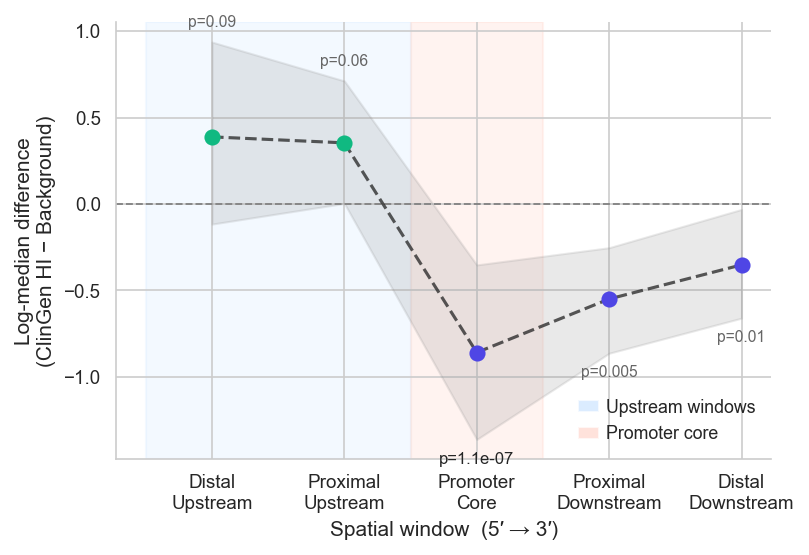

[save_plot] Saved: final_figure_04_plot5_spatial_log_median_difference_14032026_1455.pdf
[save_plot] Saved: final_figure_04_plot5_spatial_log_median_difference_14032026_1455.svg

Spatial log-median difference (ClinGen HI − Background):
              window   t_obs   ci_lo   ci_hi  pvalue
    Distal\nUpstream  0.3895 -0.1155  0.9387  0.0910
  Proximal\nUpstream  0.3549  0.0042  0.7135  0.0596
      Promoter\nCore -0.8592 -1.3625 -0.3519  0.0000
Proximal\nDownstream -0.5492 -0.8634 -0.2521  0.0046
  Distal\nDownstream -0.3517 -0.6602 -0.0306  0.0120


<Figure size 960x720 with 0 Axes>

In [94]:
import warnings
warnings.filterwarnings('ignore')

EPS = 1e-12

SPATIAL_WINDOWS = [
    ('Distal\nUpstream',     'vg_distal_upstream'),
    ('Proximal\nUpstream',   'vg_proximal_upstream'),
    ('Promoter\nCore',       'vg_promoter_core'),
    ('Proximal\nDownstream', 'vg_down_proximal'),
    ('Distal\nDownstream',   'vg_down_distal'),
]

N_BOOT = 2000
rng = np.random.default_rng(42)

records = []
for label, col in SPATIAL_WINDOWS:
    hi_vals = df_hi[col].drop_nulls().to_numpy().astype(float)
    bg_vals = df_bg[col].drop_nulls().to_numpy().astype(float)

    # Log-median difference — same metric as the 1k-permutation null model
    hi_log = np.log(hi_vals + EPS)
    bg_log = np.log(bg_vals + EPS)
    t_obs  = np.median(hi_log) - np.median(bg_log)

    # Mann-Whitney U (two-sided, rank-based → same result on raw or log)
    _, pval = stats.mannwhitneyu(hi_vals, bg_vals, alternative='two-sided')

    # Bootstrap 95% CI for the log-median difference
    boot = np.array([
        np.median(rng.choice(hi_log, len(hi_log), replace=True))
        - np.median(rng.choice(bg_log, len(bg_log), replace=True))
        for _ in range(N_BOOT)
    ])
    ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])

    records.append({'window': label, 'col': col,
                    't_obs': t_obs, 'ci_lo': ci_lo, 'ci_hi': ci_hi,
                    'pvalue': pval})

lfc_df = pd.DataFrame(records)

# ── Plot ──────────────────────────────────────────────────────────────────────
def _pval_str(p):
    if p < 0.001:  return f'p={p:.1e}'
    elif p < 0.01: return f'p={p:.3f}'
    else:          return f'p={p:.2f}'

with autosave ('04_plot5_spatial_log_median_difference', notebook=NOTEBOOK_NAME):
    fig, ax = plt.subplots(figsize=(5.5, 3.8))
    xs = np.arange(len(lfc_df))

    # Background shading: upstream vs core vs downstream
    ax.axvspan(-0.5, 1.5, color='#cce5ff', alpha=0.22, zorder=0, label='Upstream')
    ax.axvspan( 1.5, 2.5, color='#ffd6cc', alpha=0.28, zorder=0, label='Core')

    ax.axhline(0, color='#444444', lw=0.9, ls='--', alpha=0.55, zorder=1)

    # 95% CI ribbon
    ax.fill_between(xs, lfc_df['ci_lo'], lfc_df['ci_hi'],
                    color='#888888', alpha=0.18, zorder=2)

    # Connecting line
    ax.plot(xs, lfc_df['t_obs'], color='#222222', lw=1.5, ls='--', alpha=0.75, zorder=3)

    # Points: colour by direction + significance
    for i, row in lfc_df.iterrows():
        p, t = row['pvalue'], row['t_obs']
        if t > 0:   # enriched
            fc = SOURCE_PALETTE['clingen'] if p < 0.10 else '#aabbcc'
        else:       # depleted
            fc = SOURCE_PALETTE['background'] if p < 0.05 else '#ccaaaa'
        ax.scatter(i, t, color=fc, s=60, zorder=5, linewidths=0)

    # p-value text annotations
    for i, row in lfc_df.iterrows():
        p, t = row['pvalue'], row['t_obs']
        ref_y = row['ci_hi'] if t >= 0 else row['ci_lo']
        offset = 0.07 if t >= 0 else -0.07
        va = 'bottom' if t >= 0 else 'top'
        if p < 0.001:
            ax.text(i, ref_y + offset, _pval_str(p), ha='center', va=va,
                    fontsize=8, linespacing=1.4)
        elif p < 0.10:
            ax.text(i, ref_y + offset, _pval_str(p), ha='center', va=va,
                    fontsize=7.5, color='#666666', linespacing=1.4)

    ax.set_xticks(xs)
    ax.set_xticklabels([r['window'] for _, r in lfc_df.iterrows()], fontsize=9)
    ax.set_ylabel('Log-median difference\n(ClinGen HI \u2212 Background)', fontsize=10)
    ax.set_xlabel("Spatial window  (5\u2032 \u2192 3\u2032)", fontsize=10)
    ax.tick_params(labelsize=9)

    from matplotlib.patches import Patch
    legend_els = [
        Patch(fc='#cce5ff', alpha=0.7, label='Upstream windows'),
        Patch(fc='#ffd6cc', alpha=0.7, label='Promoter core'),
    ]
    ax.legend(handles=legend_els, fontsize=8.5, frameon=False,
              handlelength=1.2, handletextpad=0.4, loc='lower right')

    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()

print('\nSpatial log-median difference (ClinGen HI \u2212 Background):')
print(lfc_df[['window', 't_obs', 'ci_lo', 'ci_hi', 'pvalue']].to_string(index=False, float_format='{:.4f}'.format))


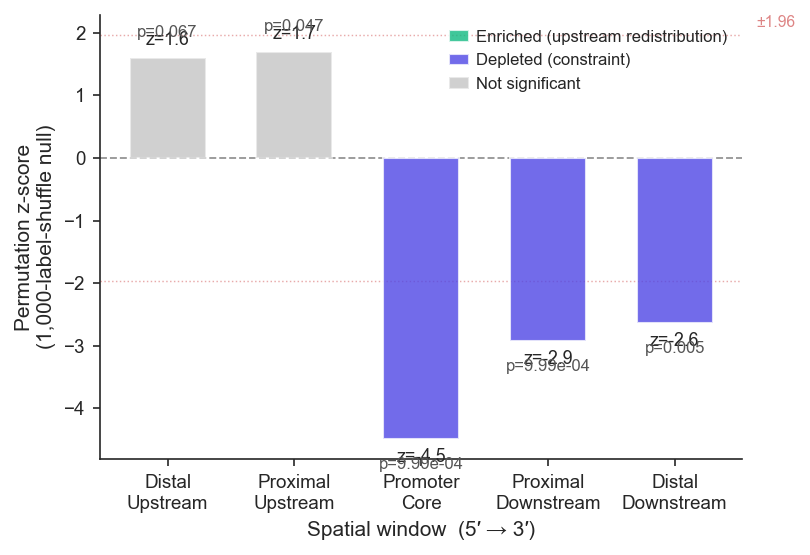


Permutation z-scores:
               label   t_obs       z  p_depletion  p_enrichment
    Distal\nUpstream  0.3895  1.5986       0.9341        0.0669
  Proximal\nUpstream  0.3549  1.6979       0.9540        0.0470
      Promoter\nCore -0.8592 -4.4895       0.0010        1.0000
Proximal\nDownstream -0.5492 -2.9284       0.0010        1.0000
  Distal\nDownstream -0.3517 -2.6427       0.0050        0.9960


In [95]:
# ── 1,000-label-shuffle permutation null model ────────────────────────────────
# For each replicate: shuffle all gene labels (HI / BG), compute log-median
# difference, build null distribution, derive z-score and empirical p-value.

EPS = 1e-12

PERM_WINDOWS = [
    ('Distal\nUpstream',     'vg_distal_upstream'),
    ('Proximal\nUpstream',   'vg_proximal_upstream'),
    ('Promoter\nCore',       'vg_promoter_core'),
    ('Proximal\nDownstream', 'vg_down_proximal'),
    ('Distal\nDownstream',   'vg_down_distal'),
]

pool_cols = ['gene_id', 'source'] + [c for _, c in PERM_WINDOWS]
pool_df   = df_real.select(pool_cols)

hi_mask = (pool_df['source'] == 'clingen').to_numpy()
n_hi    = int(hi_mask.sum())
n_total = len(pool_df)

# Log-transform once
pool_log = {
    lbl: np.log(pool_df[col].to_numpy().astype(float) + EPS)
    for lbl, col in PERM_WINDOWS
}

# Observed statistics
T_obs = {
    lbl: np.median(v[hi_mask]) - np.median(v[~hi_mask])
    for lbl, v in pool_log.items()
}

# 1,000 permutations
N_PERM  = 1_000
rng_p   = np.random.default_rng(42)
all_idx = np.arange(n_total)
W       = len(PERM_WINDOWS)
labels  = [lbl for lbl, _ in PERM_WINDOWS]

perm_matrix = np.zeros((N_PERM, W))
for p in range(N_PERM):
    shuf   = rng_p.permutation(all_idx)
    hi_idx = shuf[:n_hi]
    for j, (lbl, _) in enumerate(PERM_WINDOWS):
        v = pool_log[lbl]
        perm_matrix[p, j] = np.median(v[hi_idx]) - np.median(v[shuf[n_hi:]])

# z-scores + empirical p-values
perm_results = []
for j, (lbl, col) in enumerate(PERM_WINDOWS):
    null  = perm_matrix[:, j]
    t     = T_obs[lbl]
    z     = (t - null.mean()) / null.std()
    # lower-tail: depletion test; upper-tail: enrichment test
    p_lo  = (np.sum(null <= t) + 1) / (N_PERM + 1)
    p_up  = (np.sum(null >= t) + 1) / (N_PERM + 1)
    perm_results.append({
        'label': lbl, 't_obs': t, 'z': z,
        'p_depletion': p_lo, 'p_enrichment': p_up,
        'null_mean': null.mean(), 'null_std': null.std(),
    })

z_df = pd.DataFrame(perm_results)

# ── Plot ──────────────────────────────────────────────────────────────────────
HI_COLOR = SOURCE_PALETTE['clingen']
BG_COLOR = SOURCE_PALETTE['background']
NS_COLOR = '#aaaaaa'

def _bar_color(z):
    if z < -1.96: return BG_COLOR   # significantly depleted
    if z >  1.96: return HI_COLOR   # significantly enriched
    return NS_COLOR

def _bar_alpha(z):
    return 0.80 if abs(z) > 1.96 else 0.55

with sns.axes_style('ticks'):
    fig, ax = plt.subplots(figsize=(5.5, 3.8))
    xs = np.arange(len(z_df))

    ax.axhline(0,    color='#444444', lw=0.9, ls='--', alpha=0.55, zorder=1)
    ax.axhline( 1.96, color='#cc4444', lw=0.7, ls=':', alpha=0.45, zorder=1)
    ax.axhline(-1.96, color='#cc4444', lw=0.7, ls=':', alpha=0.45, zorder=1)
    ax.text(len(z_df) - 0.05, 2.04, '\u00b11.96', ha='right', va='bottom',
            fontsize=7.5, color='#cc4444', alpha=0.65)

    # Bars
    for i, row in z_df.iterrows():
        ax.bar(i, row['z'], color=_bar_color(row['z']),
               alpha=_bar_alpha(row['z']), width=0.6, zorder=2)

    # z-score labels on bars
    for i, row in z_df.iterrows():
        z = row['z']
        offset = 0.14 if z >= 0 else -0.14
        va = 'bottom' if z >= 0 else 'top'
        ax.text(i, z + offset, f'z={z:.1f}', ha='center', va=va, fontsize=8.5)

    # p-value annotations (significant depletions + borderline enrichments)
    for i, row in z_df.iterrows():
        z = row['z']
        if z < -1.96:
            p = row['p_depletion']
            pstr = f'p={p:.3f}' if p >= 0.001 else f'p={p:.2e}'
            ax.text(i, z - 0.28, pstr, ha='center', va='top', fontsize=8, color='#555555')
        elif z > 1.40:
            p = row['p_enrichment']
            pstr = f'p={p:.3f}' if p >= 0.001 else f'p={p:.2e}'
            ax.text(i, z + 0.28, pstr, ha='center', va='bottom', fontsize=8, color='#555555')

    ax.set_xticks(xs)
    ax.set_xticklabels([r['label'] for _, r in z_df.iterrows()], fontsize=9)
    ax.set_ylabel('Permutation z-score\n(1,000-label-shuffle null)', fontsize=10)
    ax.set_xlabel("Spatial window  (5\u2032 \u2192 3\u2032)", fontsize=10)
    ax.tick_params(labelsize=9)

    from matplotlib.patches import Patch
    legend_els = [
        Patch(fc=HI_COLOR, alpha=0.80, label='Enriched (upstream redistribution)'),
        Patch(fc=BG_COLOR, alpha=0.80, label='Depleted (constraint)'),
        Patch(fc=NS_COLOR, alpha=0.55, label='Not significant'),
    ]
    ax.legend(handles=legend_els, fontsize=8, frameon=False,
              handlelength=1.2, handletextpad=0.4)

    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()

print('\nPermutation z-scores:')
print(z_df[['label', 't_obs', 'z', 'p_depletion', 'p_enrichment']].to_string(
    index=False, float_format='{:.4f}'.format))


In [96]:
# ── SLIDE 5: Permutation null validates spatial asymmetry ────────────────────────────────────────
#
# Biological question
#   Are the observed group differences (HI vs BG) genuine, or could they arise
#   from randomly splitting the gene pool into two groups of matching size?
#
# Design
#   x-axis : Log-median difference (T = median_log_HI − median_log_BG)
#   y-axis : how many of the 1,000 permuted null replicates landed at that value
#   Line   : observed T (real ClinGen HI vs background labels)
#   Shaded : empirical p-value tail (how many null replicates are MORE extreme)
#
# Direction-specific p-values (pre-specified from NB01):
#   Depleted windows  → left-tail test  (obs T small  → HI ranked lower)
#   Elevated windows  → right-tail test (obs T large  → HI ranked higher)
#
# Relies on variables from the permutation cell above:
#   perm_matrix, T_obs, PERM_WINDOWS, N_PERM, hi_mask, all_idx, n_hi, EPS
# ---------------------------------------------------------------------------

SLIDE5_ORDER = ['total', 'promoter_core', 'proximal_upstream',
                'distal_upstream', 'down_proximal', 'down_distal']

SLIDE5_LABELS = {
    'total':             'Total Vg',
    'promoter_core':     'Promoter core
(TSS ±200 bp)',
    'proximal_upstream': 'Proximal upstream
(−2 kb to −200 bp)',
    'distal_upstream':   'Distal upstream
(−10 to −2 kb)',
    'down_proximal':     'Proximal downstream
(+200 bp to +2 kb)',
    'down_distal':       'Distal downstream
(+2 to +10 kb)',
}

IS_DEPLETED = {
    'total': True, 'promoter_core': True,
    'proximal_upstream': False, 'distal_upstream': False,
    'down_proximal': True, 'down_distal': True,
}

# Map short keys → perm_matrix column index (order from PERM_WINDOWS in cell above)
_PERM_IDX = {
    'distal_upstream':   0,
    'proximal_upstream': 1,
    'promoter_core':     2,
    'down_proximal':     3,
    'down_distal':       4,
}

# Compute total Vg (vg_predicted) permutation null using same pool/masks as above
_v_total = np.log(df_real['vg_predicted'].to_numpy().astype(float) + EPS)
_T_obs_total = np.median(_v_total[hi_mask]) - np.median(_v_total[~hi_mask])
_rng_s5 = np.random.default_rng(17)
_null_total = np.zeros(N_PERM)
for _p in range(N_PERM):
    _shuf = _rng_s5.permutation(all_idx)
    _null_total[_p] = (np.median(_v_total[_shuf[:n_hi]]) -
                       np.median(_v_total[_shuf[n_hi:]]))

# Collect null distributions and observed statistics
_perm_null = {'total': _null_total}
_T_obs_all = {'total': _T_obs_total}
for _key, _j in _PERM_IDX.items():
    _lbl = PERM_WINDOWS[_j][0]
    _perm_null[_key] = perm_matrix[:, _j]
    _T_obs_all[_key] = T_obs[_lbl]

C_DEPLETED   = '#f87171'
C_ELEVATED   = '#60a5fa'
C_NULL       = '#d1d5db'

fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)
axes_flat = axes.flatten()

for ax, w in zip(axes_flat, SLIDE5_ORDER):
    null_t   = _perm_null[w]
    obs_t    = _T_obs_all[w]
    depleted = IS_DEPLETED[w]

    null_mean = null_t.mean()
    null_sd   = null_t.std()
    z         = (obs_t - null_mean) / null_sd

    line_color = C_DEPLETED if depleted else C_ELEVATED
    fill_color = '#fca5a5' if depleted else '#93c5fd'

    # ── Null histogram ──────────────────────────────────────────────────────────────────
    counts, bin_edges = np.histogram(null_t, bins=40)
    ax.bar(bin_edges[:-1], counts, width=np.diff(bin_edges),
           color=C_NULL, alpha=0.85, align='edge', label='Null (1,000 perm.)', zorder=1)

    # Shade the tail beyond observed
    if depleted:
        tail_mask = bin_edges[1:] <= obs_t   # bins entirely left of obs
    else:
        tail_mask = bin_edges[:-1] >= obs_t  # bins entirely right of obs
    ax.bar(bin_edges[:-1][tail_mask], counts[tail_mask],
           width=np.diff(bin_edges)[tail_mask],
           color=fill_color, alpha=0.85, align='edge', zorder=2)

    # ── Reference lines ───────────────────────────────────────────────────────────────────
    ax.axvline(obs_t,     color=line_color, lw=2.5, zorder=5, label='Observed T')
    ax.axvline(null_mean, color='#9ca3af',  lw=1.2, ls='--', alpha=0.7, label='Null mean')

    # ── Direction-specific empirical p-value ────────────────────────────────────────────
    if depleted:
        p_emp = (float(np.sum(null_t <= obs_t)) + 1) / (N_PERM + 1)
    else:
        p_emp = (float(np.sum(null_t >= obs_t)) + 1) / (N_PERM + 1)

    sig       = '***' if p_emp < 0.001 else ('**' if p_emp < 0.01 else ('*' if p_emp < 0.05 else 'n.s.'))
    direction = '↓ depleted in HI' if depleted else '↑ elevated in HI'

    # ── Axes ──────────────────────────────────────────────────────────────────────────────
    ax.set_xlabel('Log-median difference (HI − BG)', fontsize=9)
    ax.set_ylabel('Count (permutations)', fontsize=9)
    ax.set_title(SLIDE5_LABELS.get(w, w), fontsize=10, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_facecolor('#fff5f5' if depleted else '#eff6ff')

    ax.text(0.97, 0.97,
            f'z = {z:+.1f}σ
p = {p_emp:.3f} {sig}
{direction}',
            ha='right', va='top', transform=ax.transAxes,
            fontsize=9, color=line_color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      alpha=0.90, edgecolor=line_color, linewidth=0.8))

for ax in axes_flat[len(SLIDE5_ORDER):]:
    ax.set_visible(False)

fig.suptitle(
    'Observed group differences are extreme outliers relative to 1,000 label-shuffle permutations
'
    'Grey bars = null; coloured line = observed T; shaded area = empirical p-value tail',
    fontsize=11, fontweight='bold',
)

save_plot(fig=fig, title='SLIDE5_permutation_null_histograms', notebook=NOTEBOOK_NAME)
plt.show()

print('Summary (direction-specific empirical p):')
for w in SLIDE5_ORDER:
    nt = _perm_null[w]; ot = _T_obs_all[w]
    z  = (ot - nt.mean()) / nt.std()
    p  = (float(np.sum(nt <= ot)) + 1)/(N_PERM+1) if IS_DEPLETED[w] else (float(np.sum(nt >= ot)) + 1)/(N_PERM+1)
    print(f"  {SLIDE5_LABELS[w].replace(chr(10),' '):45s}  z={z:+.2f}σ  p={p:.3f}")


SyntaxError: unterminated string literal (detected at line 26) (188152691.py, line 26)

Median core variant count:  HI=136  BG=123  (MWU p=1.67e-07)
Median per-variant effect:  HI=3.355e-07  BG=8.441e-07
HI effect is 60.3% lower than Background  (MWU p=3.34e-12)


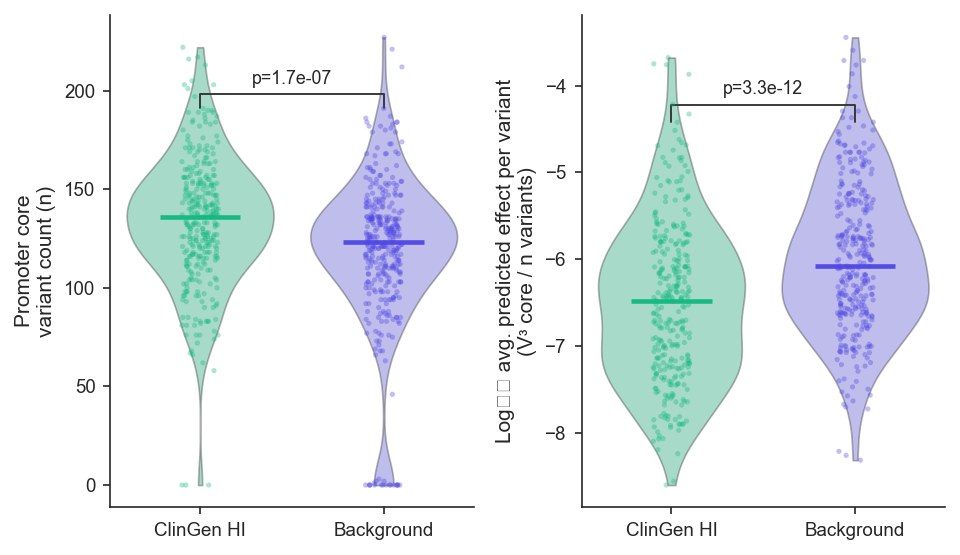

In [ ]:
# ── Biophysical: More variants, lower per-variant effect in HI core ───────────
core_col  = 'vg_promoter_core'
count_col = 'n_variants_promoter_core'

hi_core = df_hi.select(['gene_id', core_col, count_col]).to_pandas()
bg_core = df_bg.select(['gene_id', core_col, count_col]).to_pandas()
hi_core['source'] = 'ClinGen HI'
bg_core['source'] = 'Background'
core_df = pd.concat([hi_core, bg_core], ignore_index=True)

core_df['avg_eff'] = np.where(
    core_df[count_col] > 0,
    core_df[core_col] / core_df[count_col],
    np.nan
)

# ── Statistics ─────────────────────────────────────────────────────────────
hi_cnt = hi_core[count_col].dropna()
bg_cnt = bg_core[count_col].dropna()
_, p_cnt = stats.mannwhitneyu(hi_cnt, bg_cnt, alternative='two-sided')

hi_eff_ser = (hi_core[core_col] / hi_core[count_col].replace(0, np.nan)).dropna()
bg_eff_ser = (bg_core[core_col] / bg_core[count_col].replace(0, np.nan)).dropna()
_, p_eff = stats.mannwhitneyu(hi_eff_ser, bg_eff_ser, alternative='two-sided')

hi_med_n   = hi_cnt.median()
bg_med_n   = bg_cnt.median()
hi_med_eff = hi_eff_ser.median()
bg_med_eff = bg_eff_ser.median()
pct_lower  = 100.0 * (1.0 - hi_med_eff / bg_med_eff)

print(f'Median core variant count:  HI={hi_med_n:.0f}  BG={bg_med_n:.0f}  (MWU p={p_cnt:.2e})')
print(f'Median per-variant effect:  HI={hi_med_eff:.3e}  BG={bg_med_eff:.3e}')
print(f'HI effect is {pct_lower:.1f}% lower than Background  (MWU p={p_eff:.2e})')

# ── Plot ───────────────────────────────────────────────────────────────────
plot_pal = {
    'ClinGen HI': SOURCE_PALETTE['clingen'],
    'Background': SOURCE_PALETTE['background'],
}
order = ['ClinGen HI', 'Background']

plot_specs = [
    (count_col, 'Promoter core\nvariant count (n)',
     p_cnt, hi_med_n, bg_med_n, False),
    ('avg_eff', 'Avg. predicted effect per variant\n(V\u1d9f core / n variants)',
     p_eff, hi_med_eff, bg_med_eff, True),
]

with sns.axes_style('ticks'):
    fig, axes = plt.subplots(1, 2, figsize=(6.5, 3.8))

    for ax, (ycol, ylabel, pval, med_hi, med_bg, log_scale) in zip(axes, plot_specs):
        sub = core_df.dropna(subset=[ycol]).copy()

        if log_scale:
            sub[ycol] = np.log10(sub[ycol].clip(lower=1e-15))
            med_hi_plot = np.log10(max(med_hi, 1e-15))
            med_bg_plot = np.log10(max(med_bg, 1e-15))
            ylabel = ylabel.replace('Avg.', 'Log\u2081\u2080 avg.')
        else:
            med_hi_plot = med_hi
            med_bg_plot = med_bg

        sns.violinplot(data=sub, x='source', y=ycol, order=order, hue='source',
                       palette=plot_pal, legend=False, ax=ax,
                       cut=0, inner=None, linewidth=0.8, alpha=0.40)
        sns.stripplot(data=sub, x='source', y=ycol, order=order, hue='source',
                      palette=plot_pal, legend=False, ax=ax,
                      size=2.5, alpha=0.35, jitter=True, linewidth=0)

        # Median lines
        for xi, med in enumerate([med_hi_plot, med_bg_plot]):
            ax.hlines(med, xi - 0.22, xi + 0.22, lw=2.2,
                      colors=list(plot_pal.values())[xi], alpha=0.95, zorder=6)

        # Stat bracket
        y_max = sub[ycol].quantile(0.96)
        y_rng = sub[ycol].quantile(0.96) - sub[ycol].quantile(0.04)
        h = y_rng * 0.06
        ax.plot([0, 0, 1, 1],
                [y_max + h, y_max + 2*h, y_max + 2*h, y_max + h],
                lw=0.9, color='#333333')
        pstr = f'p={pval:.1e}' if pval < 0.01 else f'p={pval:.2f}'
        ax.text(0.5, y_max + 2.4*h, pstr, ha='center', va='bottom', fontsize=8.5)

        ax.set_xlabel('')
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_xticklabels(order, fontsize=9)
        ax.tick_params(labelsize=9)
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()


In [ ]:
# ── Summary statistics for thesis text ────────────────────────────────────────
print('=' * 68)
print('KEY NUMBERS FOR THESIS TEXT')
print('=' * 68)

print('\n--- Figure A: Spatial LFC gradient (log-median difference) ---')
for _, row in lfc_df.iterrows():
    direction = '\u25b2 enriched' if row['t_obs'] > 0 else '\u25bc depleted'
    print(f"  {row['window'].replace(chr(10),' '):22s}  T={row['t_obs']:+.4f}  "
          f"[{row['ci_lo']:+.3f}, {row['ci_hi']:+.3f}]  MWU p={row['pvalue']:.2e}  {direction}")

print('\n--- Figure B: Permutation z-scores (N=1,000 label-shuffle) ---')
for _, row in z_df.iterrows():
    lbl = row['label'].replace('\n', ' ')
    if row['z'] < 0:
        p_show = row['p_depletion']
        side = 'depletion'
    else:
        p_show = row['p_enrichment']
        side = 'enrichment'
    print(f"  {lbl:22s}  z={row['z']:+.2f}  p({side})={p_show:.3f}")

print('\n--- Figure C: Biophysical (promoter core) ---')
print(f"  Median variant count:  HI={hi_med_n:.0f}  BG={bg_med_n:.0f}  "
      f"ratio={hi_med_n/bg_med_n:.2f}x  (p={p_cnt:.2e})")
print(f"  Median per-var effect: HI={hi_med_eff:.3e}  BG={bg_med_eff:.3e}")
print(f"  HI effect is {pct_lower:.1f}% lower than Background  (p={p_eff:.2e})")
print('=' * 68)


KEY NUMBERS FOR THESIS TEXT

--- Figure A: Spatial LFC gradient (log-median difference) ---
  Distal Upstream         T=+0.3895  [-0.116, +0.939]  MWU p=9.10e-02  ▲ enriched
  Proximal Upstream       T=+0.3549  [+0.004, +0.713]  MWU p=5.96e-02  ▲ enriched
  Promoter Core           T=-0.8592  [-1.363, -0.352]  MWU p=1.15e-07  ▼ depleted
  Proximal Downstream     T=-0.5492  [-0.863, -0.252]  MWU p=4.63e-03  ▼ depleted
  Distal Downstream       T=-0.3517  [-0.660, -0.031]  MWU p=1.20e-02  ▼ depleted

--- Figure B: Permutation z-scores (N=1,000 label-shuffle) ---
  Distal Upstream         z=+1.60  p(enrichment)=0.067
  Proximal Upstream       z=+1.70  p(enrichment)=0.047
  Promoter Core           z=-4.49  p(depletion)=0.001
  Proximal Downstream     z=-2.93  p(depletion)=0.001
  Distal Downstream       z=-2.64  p(depletion)=0.005

--- Figure C: Biophysical (promoter core) ---
  Median variant count:  HI=136  BG=123  ratio=1.11x  (p=1.67e-07)
  Median per-var effect: HI=3.355e-07  BG=8.441e